 aba regression algorithm hamle use garirakhya xam bhane tesma chai accuracy bhanne kura hudena tei bhayera there are some regresiion metircs that are used to fin the efficeincu of an algorithm.

1. MAE (mean absolute error)
2. MSE (mean square error)
3. RMSE (root mean square error)
4. R2 score
5. Adjusted R2 score

#### 1. MAE (mean abosulte error)
   * input ra output bata hamle regression line draw garem re ani aba hamle mae ma chai harek point bata kati ko galti bhairako xa or error kati ko xa harek points ko tyo nikalxa | y1 - y1(hat) | + | y2 - y2(hat)| this is total error now we can divide the total by 'n' to make an mean of the error.
   * Advantage
     - Mean abosulte is basicall loss of each points. So it should be very minimum.Unit chai output colum mai auxa so it is very easy to understand(same unit)
     - If there is any outlier in data then it is very robust
    * Disadvantage
      - The graph is not differentiable in this so we using MSE 

#### 2. MSE(mean sqaure error)
   * tei MAE  ko nai formula ma mod use nagarerra use use square (y-y)^2 use garne ani tespaxi n le divide garidine mse ma chai mod hudena square garne simply
     thus is becomes (y - y(hat))^2 divided by n.
   * Advantage
     - We ca use it as a loss function which is biggest advantage.
   * Disadvantage
     - Outlier are penalized.So loss function penalized outlier very much.

#### 3. RMSE (root mean square error)
   * is is simply sqrt(MSE) this sqrt((y-y(hat))^2) / n gardine simply it is the root of mean sqaure error.
   * Advantage
     - graph is differentiable
     - interpretation is easy
    * Disadvantages
      - It penalizes outlier very much so it is robust to outlier.


It is used very widely in Deep Learning.Simply use all 3 of them while using simple regression.

#### 4. R2 score
Mse and mae depend on the context but r2 score donot depend on the context. for example |cgpa| package(lpa)| is the given column suppose if you dont have cgpa and only package column then you would determine by taking the mean of the package and give conclusion. In r2 score we compare that the value of linear regression and mean how much the difference is there between value from linear regression and mean it is also known as coefficient of determination and also known as goodness of fit esma chai hamle mean ra linear regression lai compare garne ho.

Formula of R2 score = 1 - SSr / SSm

 - SSr = sum of squared error in regression line
 - SSm = sum of squared error in mean line 

mean line ra regression line sanga compare garira the worst one is the mean line and the best line is the regression line so we basically compare the linear regression and mean
##### Disadvantage of R2 score
if there is more input column in the data after adding the data into it then the r2score will also increase as we increase the data. If we add irrelevant features in the column then also r2 score will be increase which is not appropriate 

#### 4.Adjusted R2 score

$$
R2_{\text{adjusted}} = 1 - \left( \frac{(1 - R2)(n - 1)}{n - 1 - k} \right)$$$
$


- Relevant column add garyo bhane hamro R2 adjusted in badxa
- Relevant column xaina ani add garyo bhane hamro R2 adjusted ghatxa

In [74]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [76]:
df = pd.read_csv('placement.csv')

In [78]:
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


Text(0, 0.5, 'Package (in LPA)')

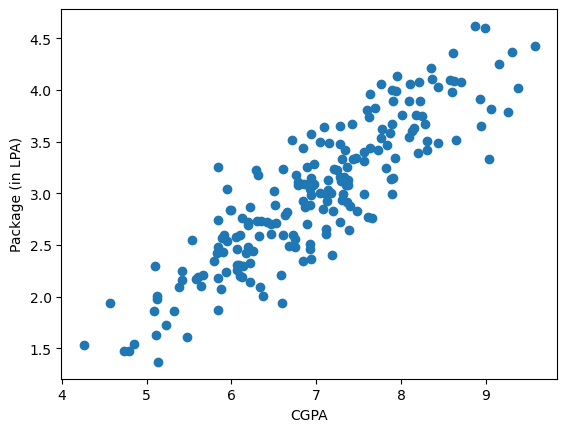

In [82]:
plt.scatter(df['cgpa'], df['package'])
plt.xlabel("CGPA")
plt.ylabel("Package (in LPA)")

In [84]:
X = df.iloc[: , 0:1]

In [86]:
y = df.iloc[: , -1]

In [88]:
y


0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [90]:
from sklearn.model_selection import train_test_split

In [92]:
X_train , X_test , y_train , y_test = train_test_split(X , y , test_size = 0.2 , random_state = 2)

In [96]:
from sklearn.linear_model import LinearRegression

In [98]:
lr = LinearRegression()

In [100]:
lr.fit(X_train , y_train)

LinearRegression()

Text(0, 0.5, 'Package(in LPA)')

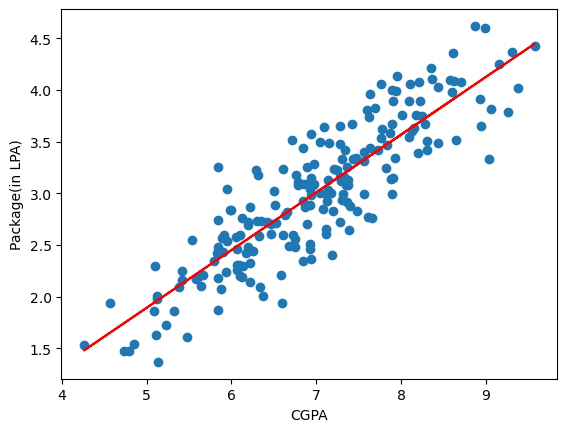

In [102]:
plt.scatter(df['cgpa'] , df['package'])
plt.plot(X_train , lr.predict(X_train) , color = 'red')
plt.xlabel('CGPA')
plt.ylabel('Package(in LPA)')

Now calculate MSE , MAE , RMSE , R2score , Adjusted R2 score

In [109]:
from sklearn.metrics import mean_absolute_error , mean_squared_error , r2_score

In [115]:
y_pred = lr.predict(X_test)

In [117]:
y_test.values

array([4.1 , 3.49, 2.08, 2.33, 1.94, 1.48, 1.86, 3.09, 4.21, 2.87, 3.65,
       4.  , 2.89, 2.6 , 2.99, 3.25, 1.86, 3.67, 2.37, 3.42, 2.48, 3.65,
       2.6 , 2.83, 4.08, 2.56, 3.58, 3.81, 4.09, 2.01, 3.63, 2.92, 3.51,
       1.94, 2.21, 3.34, 3.34, 3.23, 2.01, 2.61])

In [121]:
print("MAE", mean_absolute_error(y_test , y_pred))

MAE 0.2884710931878175


In [129]:
print("MSE", mean_squared_error(y_test , y_pred))

MSE 0.12129235313495527


In [133]:
print("MAE", np.sqrt(mean_squared_error(y_test , y_pred)))

MAE 0.34827051717731616


In [141]:
# Accuracy score jastai ho yo chai
print("MAE", r2_score(y_test , y_pred))
r2 = r2_score(y_test , y_pred)

MAE 0.780730147510384


In [145]:
# adjusted r2_score 
X_test.shape

(40, 1)

#### Adjusted R2 score

In [150]:
1 - (((1-r2)*(40-1)) / (40-1-1))

0.7749598882343415